In [116]:
import pandas as pd

In [117]:
data= pd.read_csv("pakistan_properties.csv")

In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838 entries, 0 to 1837
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    1838 non-null   object 
 1   Price                    1838 non-null   object 
 2   Price_in_PKR             1838 non-null   int64  
 3   Area                     1838 non-null   object 
 4   Area_in_Sqft             1538 non-null   float64
 5   City                     1838 non-null   object 
 6   Sub_Location             1838 non-null   object 
 7   Location                 1838 non-null   object 
 8   Full_Location            1838 non-null   object 
 9   Bedrooms                 1716 non-null   float64
 10  Bathrooms                1681 non-null   float64
 11  Property_Type            1838 non-null   object 
 12  Built_Year               1352 non-null   float64
 13  Parking_Spaces           1838 non-null   int64  
 14  Servant_Quarters        

In [119]:
data['City'].unique()

array(['Islamabad', 'Lahore', 'Karachi', 'Rawalpindi', 'Faisalabad',
       'Peshawar', 'Jhelum'], dtype=object)

In [120]:
#data['Price (PKR)'] = data['Price (PKR)'] / 100
#data['Price_Per_Sqft'] = data['Price (PKR)'] / data['Area_in_Sqft']

In [121]:
data.head()

,Title,Price,Price_in_PKR,Area,Area_in_Sqft,City,Sub_Location,Location,Full_Location,Bedrooms,...,Drawing_Rooms,Dining_Rooms,Study_Rooms,Prayer_Rooms,Powder_Rooms,Lounge_or_Sitting_Rooms,Laundry_Rooms,Floors,Furnished,URL
0,"HEIGHTED CUTTING STREET 10 MARLA E-12/2, E-12,...",PKR 3.55 Crore,35500000,10 Marla,2722.5,Islamabad,E-12/2,"E-12/2, E-12, Islamabad","E-12/2, E-12, Islamabad",NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/e_12_e-12_2_he...
1,"FRONT OPEN PLOT C-15, Islamabad ID53534407 - Z...",PKR 2.9 Crore,29000000,1 Kanal,5445.0,Islamabad,C-15,"C-15, Islamabad","C-15, Islamabad",NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-15...
2,"70FT ROAD PLOT BACK OPEN C-15, Islamabad ID540...",PKR 3 Crore,30000000,1 Kanal,5445.0,Islamabad,C-15,"C-15, Islamabad","C-15, Islamabad",NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-15...
3,Corner Brand New House For Sale In D 12 D-12/1...,PKR 13 Crore,130000000,10 Marla,2722.5,Islamabad,D-12/1,"D-12/1, D-12, Islamabad","D-12/1, D-12, Islamabad",5.0,...,1,1,0,0,1,1,0,2.0,0,https://www.zameen.com/Property/d_12_d-12_1_co...
4,"INVESTOR PRICE IN C16/2 C-16, Islamabad ID5422...",PKR 2.4 Crore,24000000,1 Kanal,5445.0,Islamabad,C-16,"C-16, Islamabad","C-16, Islamabad",NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-16...


In [122]:
data = data.drop(columns=['Price','Area', 'Full_Location']) #we don;t need these as data is present in other columns
data = data.rename(columns={'Price_in_PKR': 'Price (PKR)'}) #renaming the modified column to price
display(data.head())

,Title,Price (PKR),Area_in_Sqft,City,Sub_Location,Location,Bedrooms,Bathrooms,Property_Type,Built_Year,...,Drawing_Rooms,Dining_Rooms,Study_Rooms,Prayer_Rooms,Powder_Rooms,Lounge_or_Sitting_Rooms,Laundry_Rooms,Floors,Furnished,URL
0,"HEIGHTED CUTTING STREET 10 MARLA E-12/2, E-12,...",35500000,2722.5,Islamabad,E-12/2,"E-12/2, E-12, Islamabad",NaN,NaN,Residential Plot,NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/e_12_e-12_2_he...
1,"FRONT OPEN PLOT C-15, Islamabad ID53534407 - Z...",29000000,5445.0,Islamabad,C-15,"C-15, Islamabad",NaN,NaN,Residential Plot,NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-15...
2,"70FT ROAD PLOT BACK OPEN C-15, Islamabad ID540...",30000000,5445.0,Islamabad,C-15,"C-15, Islamabad",NaN,NaN,Residential Plot,NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-15...
3,Corner Brand New House For Sale In D 12 D-12/1...,130000000,2722.5,Islamabad,D-12/1,"D-12/1, D-12, Islamabad",5.0,5.0,House,2024.0,...,1,1,0,0,1,1,0,2.0,0,https://www.zameen.com/Property/d_12_d-12_1_co...
4,"INVESTOR PRICE IN C16/2 C-16, Islamabad ID5422...",24000000,5445.0,Islamabad,C-16,"C-16, Islamabad",NaN,NaN,Residential Plot,NaN,...,0,0,0,0,0,0,0,NaN,0,https://www.zameen.com/Property/islamabad_c-16...


In [123]:
import numpy as np

#remove duplicate/and fill NA values.
data.drop_duplicates(inplace=True)

for i in ['Bedrooms', 'Bathrooms', 'Floors']:
    data[i] = data[i].fillna(data[i].median())

data['Built_Year'] = data['Built_Year'].fillna(data['Built_Year'].mode()[0])

data.isnull().sum()


,0
Title,0
Price (PKR),0
Area_in_Sqft,297
City,0
Sub_Location,0
Location,0
Bedrooms,0
Bathrooms,0
Property_Type,0
Built_Year,0


In [124]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categoricalcolumns = ['City', 'Sub_Location', 'Location', 'Property_Type']

for i in categoricalcolumns:
    data[i] = le.fit_transform(data[i].astype(str))

print(data[categoricalcolumns].dtypes)

data=data.dropna(subset=['Price (PKR)', 'Area_in_Sqft'])

City             int64
Sub_Location     int64
Location         int64
Property_Type    int64
dtype: object


### Exploratory Data Analysis (EDA)

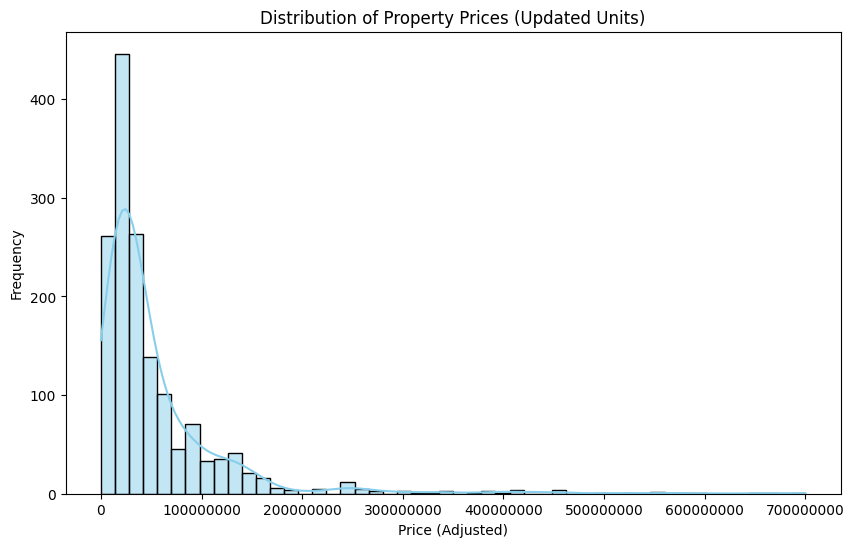

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data['Price (PKR)'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Property Prices (Updated Units)')
plt.xlabel('Price (Adjusted)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

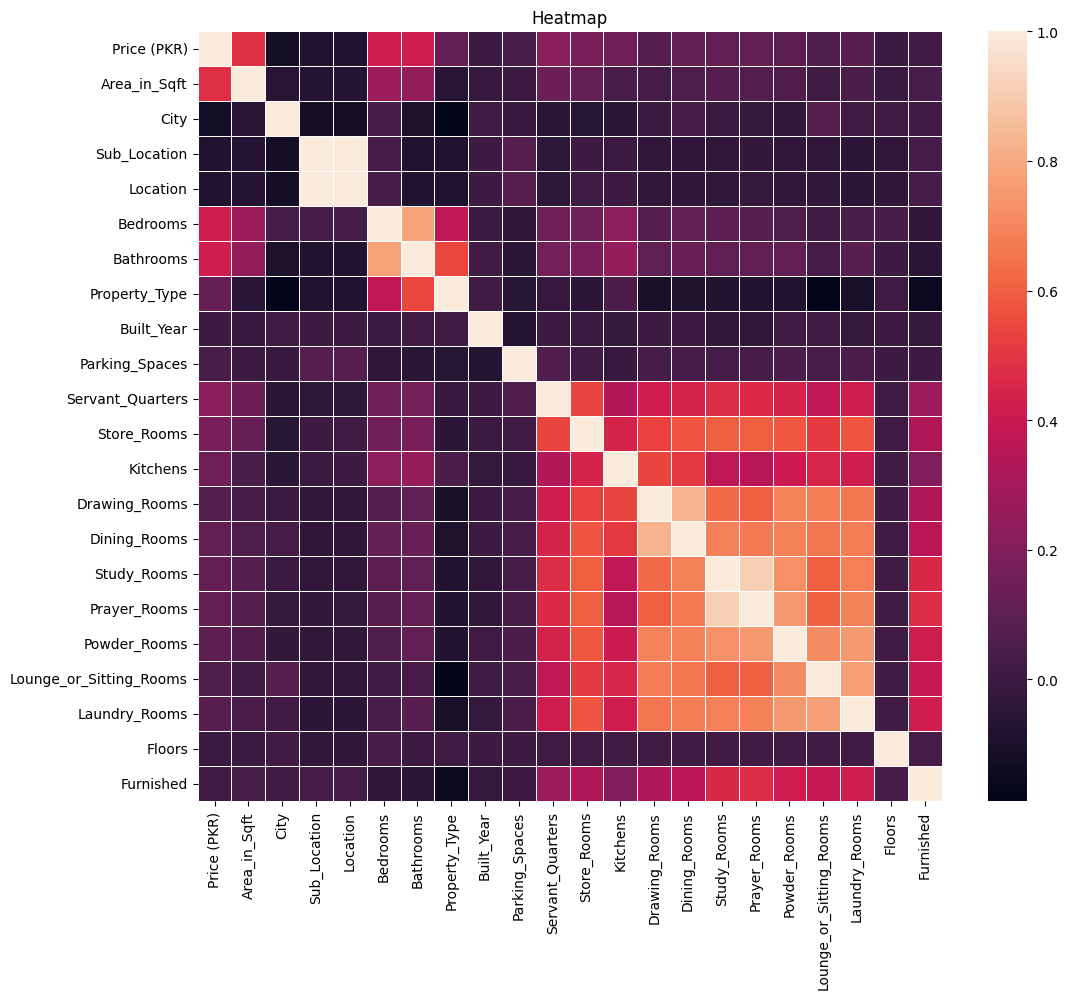

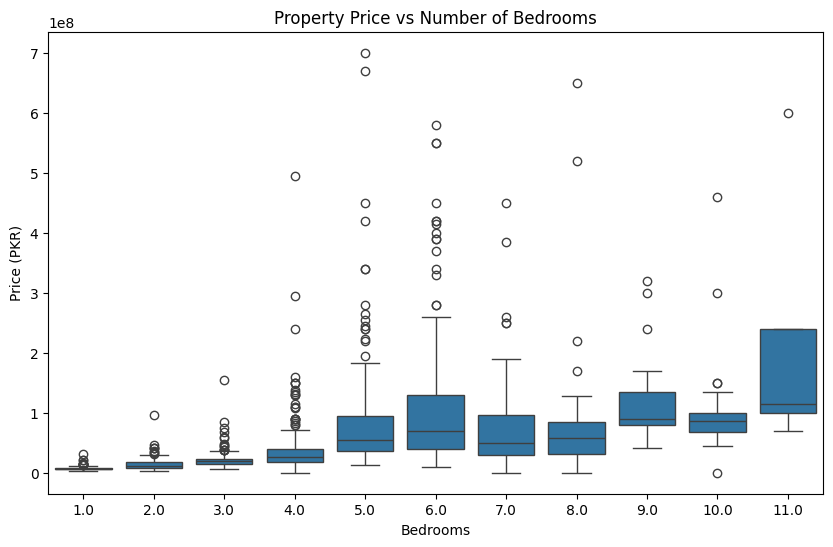

In [126]:
plt.figure(figsize=(12, 10))
corr_matrix = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, linewidths=0.5)
plt.title('Heatmap')
plt.show()

# Price vs Bedrooms
plt.figure(figsize=(10, 6))
sns.boxplot(x='Bedrooms', y='Price (PKR)', data=data)
plt.title('Property Price vs Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price (PKR)')
plt.show()

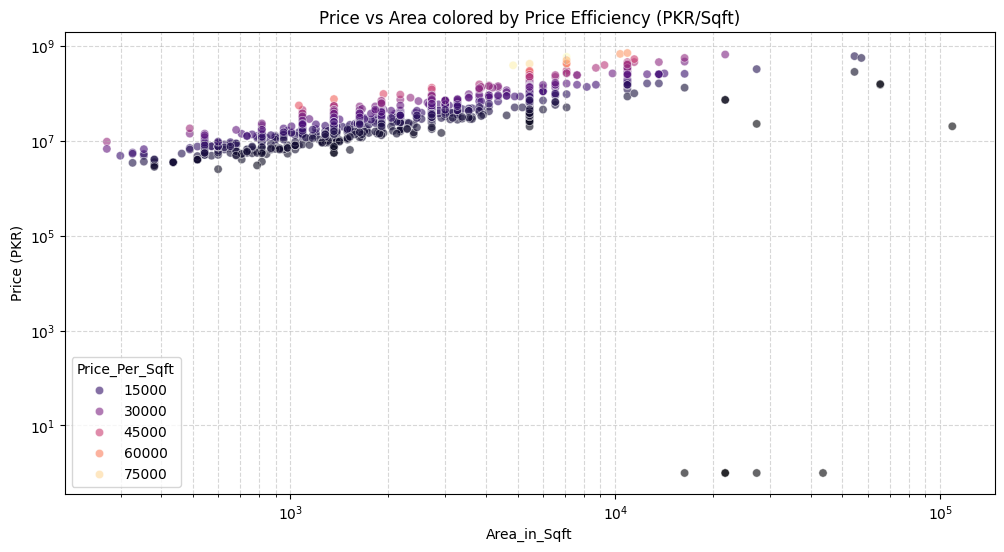

In [127]:
# Calculate Price per Square Foot
data['Price_Per_Sqft'] = data['Price (PKR)'] / data['Area_in_Sqft']

plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='Area_in_Sqft', y='Price (PKR)', hue='Price_Per_Sqft', palette='magma', alpha=0.6)
plt.title('Price vs Area colored by Price Efficiency (PKR/Sqft)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

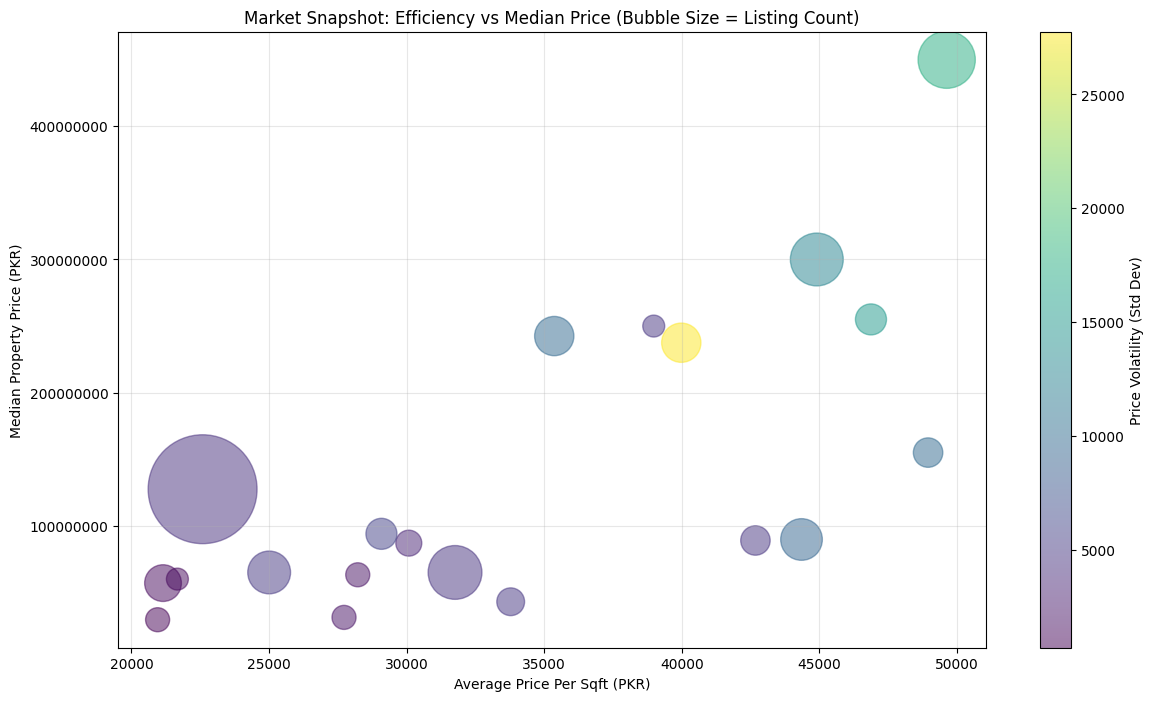

In [128]:
plt.figure(figsize=(14, 8))
bubble_data = fruitful_locations.head(20)

scatter = plt.scatter(
    bubble_data['Avg_Price_Per_Sqft'],
    bubble_data['Median_Price'],
    s=bubble_data['Listing_Count'] * 50,
    alpha=0.5,
    c=bubble_data['Price_Volatility'],
    cmap='viridis'
)

plt.colorbar(scatter, label='Price Volatility (Std Dev)')
plt.title('Market Snapshot: Efficiency vs Median Price (Bubble Size = Listing Count)')
plt.xlabel('Average Price Per Sqft (PKR)')
plt.ylabel('Median Property Price (PKR)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.show()

In [129]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Price (PKR)', 'Price_Per_Sqft', 'Title', 'URL'])
y = data['Price (PKR)']

#going with normal 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape
X_test.shape

(308, 21)

In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#model array
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=20, random_state=12),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}
#array// append later
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"MAE": mae, "R2 Score": r2}

# Convert results to a DataFrame for easy viewing
comparison = pd.DataFrame(results).T.sort_values(by='R2 Score', ascending=False)
display(comparison)

,MAE,R2 Score
XGBoost,1.312959e+07,0.836151
Gradient Boosting,1.339639e+07,0.799850
Random Forest,1.446071e+07,0.694163
Decision Tree,1.786921e+07,0.430031
Linear Regression,2.689468e+07,0.426791


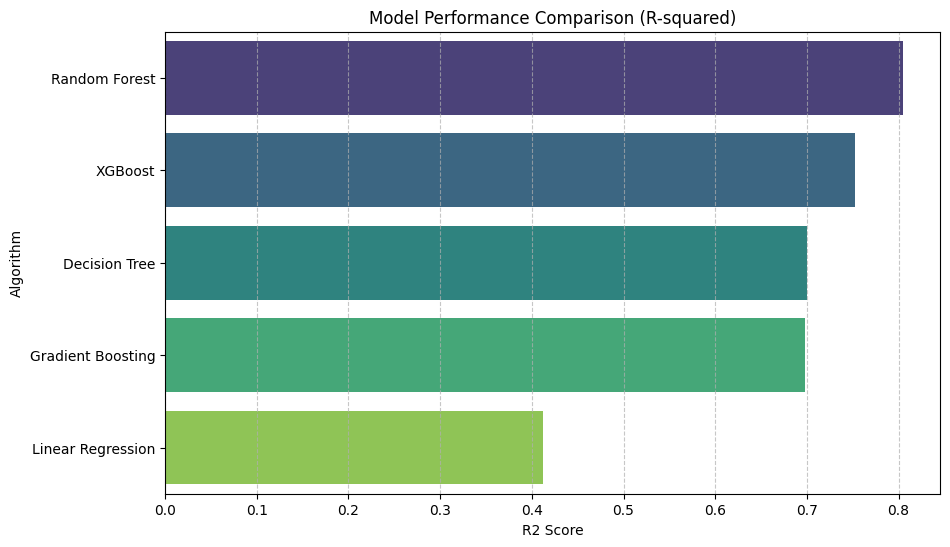

In [131]:
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df['R2 Score'], y=comparison_df.index, hue=comparison_df.index, palette='viridis', legend=False)
plt.title('Model Performance Comparison (R-squared)')
plt.xlabel('R2 Score')
plt.ylabel('Algorithm')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [134]:
import pickle

best = models['XGBoost']

# Save the model to a file
with open('property_model.pkl', 'wb') as f:
    pickle.dump(best, f)

print("Model successfully pickled!!!! Yayyy")

Model successfully pickled!!!! Yayyy
